# 10 — Changement de régime : atteindre les désinformations qui s'installent

Le [notebook 09](09_calibration_visibilite.ipynb) a livré un chiffre, mais il a surtout
révélé sa propre limite. Onze des vingt-quatre sujets du corpus n'ont produit aucun épisode
exploitable, et ce sont **les cas archétypaux** : QAnon, désinformation Covid-19, hésitation
vaccinale, grand remplacement, Pegasus. Leur attention ne forme pas un pic suivi d'une
décroissance — elle **change de niveau et s'installe**.

Un modèle de la polarisation qui ne mesure que les flambées passagères n'atteint pas son
objet. Ce notebook traite l'autre cas.

**Résultat, annoncé d'emblée.** Deux réussites doivent être distinguées, parce qu'une seule
est acquise :

* **la détection fonctionne** — 14 changements de régime sont identifiés sur le corpus, aux
  bonnes dates : l'affaire Benalla le 20 juillet 2018, les révélations Pegasus en juillet
  2021, l'annonce de LIGO en février 2016, l'explosion de QAnon en mars 2020. Et elle couvre
  précisément les sujets que la méthode par pic manquait ;
* **l'identification échoue** — sur ces mêmes séries, la dispersion résiduelle est de 0,63 en
  médiane, alors que l'incertitude relative sur $\gamma\alpha/\lambda$ atteint déjà 77 % à
  0,15. **Aucun** des 14 changements ne livre de paramètres exploitables.

À quoi s'ajoute une limite théorique découverte en route, plus lourde que les deux :
l'identifiabilité du rapport dépend de la **forme** supposée de la saturation, et pour l'une
des deux formes plausibles elle n'existe pas du tout.

## 1. Pourquoi l'estimateur par pic ne peut pas être réutilisé

L'identification par pic reposait sur deux pentes : une montée à
$\gamma\alpha - \lambda$, une décroissance à $\lambda$.

Dans un régime installé, **la décroissance n'existe pas**. Le système est à son point fixe,
où par définition $\gamma\alpha\,\sigma(V^*) = \lambda$ : le niveau du palier ne dit rien
à lui seul, et il n'y a pas de seconde pente à mesurer.

L'information est ailleurs — dans la **forme de la transition**, qui traverse tout le domaine
de la saturation et contraint les trois paramètres à la fois.

## 2. Une identification exacte, et sa fragilité

En posant $y = \dot W/W$ et $x = W^2$, un réarrangement **exact** de l'équation — sans
approximation — donne une forme linéaire en trois coefficients :

$$y = A - B\,xy - C\,x
  \qquad A = \gamma\alpha - \lambda, \quad B = \frac{1}{W_{\text{sat}}^2},
  \quad C = \frac{\lambda}{W_{\text{sat}}^2}$$

d'où $\lambda = C/B$, $\gamma\alpha = A + C/B$, et $\gamma\alpha/\lambda = 1 + AB/C$.

Cette régression retrouve les trois paramètres à la précision machine — mais elle est
inutilisable en pratique : $y$ apparaît à la fois comme réponse et dans le régresseur $-xy$,
et il faut le calculer en dérivant des données bruitées. C'est un problème d'erreurs sur les
variables, et il est dévastateur.

L'estimateur retenu n'utilise donc **aucune dérivée** : il intègre l'équation et ajuste la
trajectoire en échelle logarithmique, la forme linéaire ne servant que d'initialisation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ide.corpus import CORPUS, CORPUS_END, CORPUS_START
from ide.pageviews import load_or_fetch
from ide.plotting import PALETTE, save_figure, use_project_style
from ide.regime import (
    RegimeCriteria,
    _integrate,
    detect_change_points,
    expected_precision,
    fit_saturated_growth,
    scan_regime_shifts,
    weekly_adjust,
)

use_project_style()

def transition(ratio, damping=0.2, saturation=3_000.0, days=120):
    grid = np.arange(0.0, float(days))
    return _integrate(ratio * damping, damping, saturation, 0.01 * saturation, grid, "quadratic")

print("Récupération sur trajectoire propre — condition minimale de crédibilité :")
for ratio in (1.5, 5.0, 40.0):
    fit = fit_saturated_growth(transition(ratio))
    print(f"  ρ vrai = {ratio:5.1f}  →  ρ estimé = {fit.ratio:6.2f}   "
          f"λ = {fit.damping:.4f} (vrai 0.2)   Wsat = {fit.saturation:7.0f} (vrai 3000)")

Récupération sur trajectoire propre — condition minimale de crédibilité :
  ρ vrai =   1.5  →  ρ estimé =   1.50   λ = 0.2000 (vrai 0.2)   Wsat =    3000 (vrai 3000)
  ρ vrai =   5.0  →  ρ estimé =   5.00   λ = 0.2000 (vrai 0.2)   Wsat =    3000 (vrai 3000)


  ρ vrai =  40.0  →  ρ estimé =  40.00   λ = 0.2000 (vrai 0.2)   Wsat =    3000 (vrai 3000)


## 3. La limite théorique : l'identifiabilité dépend de la forme supposée

C'est le point le plus lourd, et il n'a rien de numérique.

Sous la saturation du modèle, $\sigma = 1/(1+(W/W_{\text{sat}})^2)$, les trois paramètres
façonnent la courbe de trois manières distinctes : ils sont séparables, comme la récupération
ci-dessus le confirme.

Sous une saturation **logistique**, $\sigma = 1 - W/W_{\text{sat}}$, l'équation devient

$$\dot W = (\gamma\alpha - \lambda)\,W\left(1 - \frac{W}{K}\right),
  \qquad K = W_{\text{sat}}\left(1 - \frac{\lambda}{\gamma\alpha}\right)$$

La trajectoire ne dépend plus que de **deux** combinaisons des trois paramètres. Le rapport
$\gamma\alpha/\lambda$ y est **structurellement non identifiable** — et aucune précision de
mesure n'y changera quoi que ce soit.

In [2]:
grid = np.arange(0.0, 120.0)

# Deux triplets de paramètres aux rapports très différents…
first = _integrate(1.0, 0.2, 3_000.0, 30.0, grid, "logistic")   # ρ = 5.00
second = _integrate(2.0, 1.2, 6_000.0, 30.0, grid, "logistic")  # ρ = 1.67

print(f"écart maximal entre les deux trajectoires : {np.max(np.abs(first - second) / first):.2e}")
print(f"rapports correspondants : {1.0/0.2:.2f} et {2.0/1.2:.2f}")
print("\nLes deux courbes sont identiques. Sous saturation logistique, aucun ajustement")
print("ne peut séparer γα de λ : l'identifiabilité est une hypothèse de forme, pas une")
print("propriété des données.")

écart maximal entre les deux trajectoires : 1.97e-14
rapports correspondants : 5.00 et 1.67

Les deux courbes sont identiques. Sous saturation logistique, aucun ajustement
ne peut séparer γα de λ : l'identifiabilité est une hypothèse de forme, pas une
propriété des données.


## 4. Détection : ce qui fonctionne

La détection procède par **segmentation binaire** sur les logarithmes — une audience évolue
multiplicativement, un doublement doit compter autant à mille qu'à cent mille consultations
par jour. À chaque étape, la coupure qui réduit le plus le coût quadratique est retenue si
elle dépasse une pénalité, ce qui évite de fixer à l'avance un nombre de ruptures.

Trois validations sont exigées avant de parler de changement de régime :

| Critère | Rôle |
|---|---|
| **maintien** sur 180 jours | c'est ce qui sépare un régime d'un pic : un pic retombe |
| **élévation** d'au moins ×2 | un déplacement de niveau, non une fluctuation |
| **ancien régime** ≥ 50 vues/jour | il faut un régime antérieur pour qu'il y ait changement : une série passant de 2 à 300 consultations décrit un article qui vient d'être rédigé |

In [3]:
print(f"{'cas':34s} {'ruptures':>9s} {'régimes':>8s}  motif de rejet")
print("-" * 72)

# Régime installé, engendré par l'équation elle-même.
regime = np.full(900, 500.0)
regime[300:] = 500.0 + transition(5.0, days=600)
regime = regime * np.random.default_rng(1).lognormal(0.0, 0.05, 900)

# Pic : même amplitude, mais qui retombe.
peak = np.full(900, 500.0)
peak[400:460] = 500.0 + 6_000.0 * np.exp(-0.10 * np.arange(60))
peak = peak * np.random.default_rng(3).lognormal(0.0, 0.06, 900)

# Bruit stationnaire : aucune rupture ne doit être inventée.
noise = np.random.default_rng(1).lognormal(np.log(800.0), 0.12, 900)

# Création d'article : élévation énorme, mais sans régime antérieur.
creation = np.full(900, 2.0)
creation[300:] = 300.0
creation = creation * np.random.default_rng(5).lognormal(0.0, 0.05, 900)

for name, series in [
    ("régime installé", regime),
    ("pic (doit être rejeté)", peak),
    ("bruit stationnaire", noise),
    ("création d'article", creation),
]:
    report = scan_regime_shifts(series, label=name, adjust_weekly=False)
    print(f"{name:34s} {report.candidates:9d} {len(report.shifts):8d}  "
          f"{report.dominant_rejection or '—'}")

cas                                 ruptures  régimes  motif de rejet
------------------------------------------------------------------------
régime installé                            2        1  —
pic (doit être rejeté)                     2        0  élévation
bruit stationnaire                         0        0  —
création d'article                         1        0  niveau


## 5. Le corpus réel

Les mêmes 24 sujets pré-enregistrés que le notebook 09, avec la correction de la périodicité
hebdomadaire — un effet systématique de 20 à 30 % d'amplitude, dont le retrait est la
préparation la plus rentable puisque c'est la dispersion résiduelle qui pilote l'incertitude.

In [4]:
records = []
for entry in CORPUS:
    series = load_or_fetch(entry.project, entry.article, CORPUS_START, CORPUS_END)
    report = scan_regime_shifts(np.clip(series.filled(), 1.0, None), label=entry.label)
    for shift in report.shifts:
        records.append({
            "classe": entry.category,
            "sujet": entry.label,
            "date": series.day(shift.index),
            "avant": shift.level_before,
            "après": shift.level_after,
            "élévation": shift.lift,
            "dispersion": shift.fit.scatter,
            "identifié": shift.has_identified_parameters,
        })

print(f"{'classe':11s} {'sujet':26s} {'date':12s} {'avant':>7s} {'après':>8s} {'×':>7s} {'disp.':>6s}")
print("-" * 82)
for row in sorted(records, key=lambda item: (item["classe"], -item["élévation"])):
    print(f"{row['classe']:11s} {row['sujet']:26s} {row['date']}  {row['avant']:7.0f} "
          f"{row['après']:8.0f} {row['élévation']:7.1f} {row['dispersion']:6.2f}")

identified = sum(row["identifié"] for row in records)
print(f"\n{len(records)} changements de régime détectés — {identified} avec paramètres exploitables")

classe      sujet                      date           avant    après       ×  disp.
----------------------------------------------------------------------------------
accusation  QAnon                      2018-03-31      165     7296    44.2   0.38
accusation  Pizzagate                  2020-03-16     3104    57239    18.4   0.54
accusation  Gilets jaunes              2019-05-03      119     1623    13.7   0.20
accusation  QAnon                      2020-03-09     4831    58534    12.1   0.35
accusation  Gilets jaunes              2019-01-30      119      746     6.3   0.29
accusation  Pegasus (logiciel espion)  2021-07-17      444     1955     4.4   0.60
accusation  Affaire Benalla            2018-07-20      191      528     2.8   0.66
accusation  Pegasus (logiciel espion)  2019-08-18      189      426     2.2   0.84
discovery   OSIRIS-REx                 2016-06-12      141      467     3.3   0.87
discovery   LIGO                       2016-01-09      224      727     3.2   0.99
dis

### Les dates sont les bonnes

C'est la validation la plus parlante de la détection : sans qu'aucune date ne lui ait été
fournie, elle retrouve des événements datables.

| Sujet | Date détectée | Événement |
|---|---|---|
| Affaire Benalla | 20 juillet 2018 | révélation de l'affaire |
| QAnon | 31 mars 2018 | émergence du mouvement |
| QAnon | 9 mars 2020 | bascule pandémique |
| Pegasus | 17 juillet 2021 | révélations du *Pegasus Project* |
| LIGO | 9 janvier 2016 | fuites précédant l'annonce |
| Ondes gravitationnelles | 1ᵉʳ février 2016 | annonce de la détection |
| Event Horizon Telescope | 1ᵉʳ avril 2019 | première image d'un trou noir |
| Télescope James-Webb | 27 septembre 2021 | approche du lancement |

Et surtout : **QAnon, la désinformation Covid-19 et l'hésitation vaccinale apparaissent
ici**, alors qu'ils étaient invisibles à la détection par pic. L'angle mort du notebook 09
est couvert — pour la détection.

## 6. L'identification échoue, et il faut le dire

Aucun des 14 changements ne livre de paramètres exploitables. La raison est mesurable : la
dispersion résiduelle médiane est de 0,63, alors que l'incertitude relative sur
$\gamma\alpha/\lambda$ atteint déjà 77 % à une dispersion de 0,15.

Les séries d'attention réelles ne sont pas seulement bruitées : elles portent des bosses
médiatiques successives superposées à la tendance, que le modèle à trois paramètres ne peut
pas absorber. L'ajustement est donc **refusé** plutôt que rapporté avec une barre d'erreur
illusoire.

Ce refus est un choix explicite. Une version antérieure de ce module tolérait une dispersion
de 0,30, et produisait des valeurs comme $\lambda = 4{,}4$ par jour — une mémoire collective
de cinq heures — ou $\rho = 139$. Ces chiffres avaient l'apparence de résultats.

In [5]:
table = {}
for scatter in (0.03, 0.05, 0.10, 0.15, 0.25):
    ratios = []
    for seed in range(8):
        series = np.full(900, 500.0)
        series[300:] = 500.0 + transition(5.0, days=600)
        series = series * np.random.default_rng(seed).lognormal(0.0, scatter, 900)
        report = scan_regime_shifts(series, adjust_weekly=False)
        ratios.extend(shift.ratio for shift in report.shifts)
    values = np.array(ratios)
    spread = (np.percentile(values, 75) - np.percentile(values, 25)) / np.median(values)
    table[scatter] = (np.median(values), spread, len(values))
    print(f"  dispersion {scatter:.2f}  →  ρ médian = {np.median(values):5.2f} (vrai 5.00), "
          f"IQR relatif = {spread:4.2f}  (n = {len(values)})")

observed = np.median([row["dispersion"] for row in records])
print(f"\nDispersion médiane observée sur les séries réelles : {observed:.2f}")
print(f"Incertitude relative correspondante : {expected_precision(min(observed, 0.25)):.0%} ou davantage")

  dispersion 0.03  →  ρ médian =  5.27 (vrai 5.00), IQR relatif = 0.07  (n = 8)


  dispersion 0.05  →  ρ médian =  5.47 (vrai 5.00), IQR relatif = 0.12  (n = 8)


  dispersion 0.10  →  ρ médian =  5.76 (vrai 5.00), IQR relatif = 0.25  (n = 8)


  dispersion 0.15  →  ρ médian =  6.04 (vrai 5.00), IQR relatif = 0.43  (n = 8)


  dispersion 0.25  →  ρ médian =  5.15 (vrai 5.00), IQR relatif = 1.18  (n = 8)

Dispersion médiane observée sur les séries réelles : 0.63
Incertitude relative correspondante : 135% ou davantage


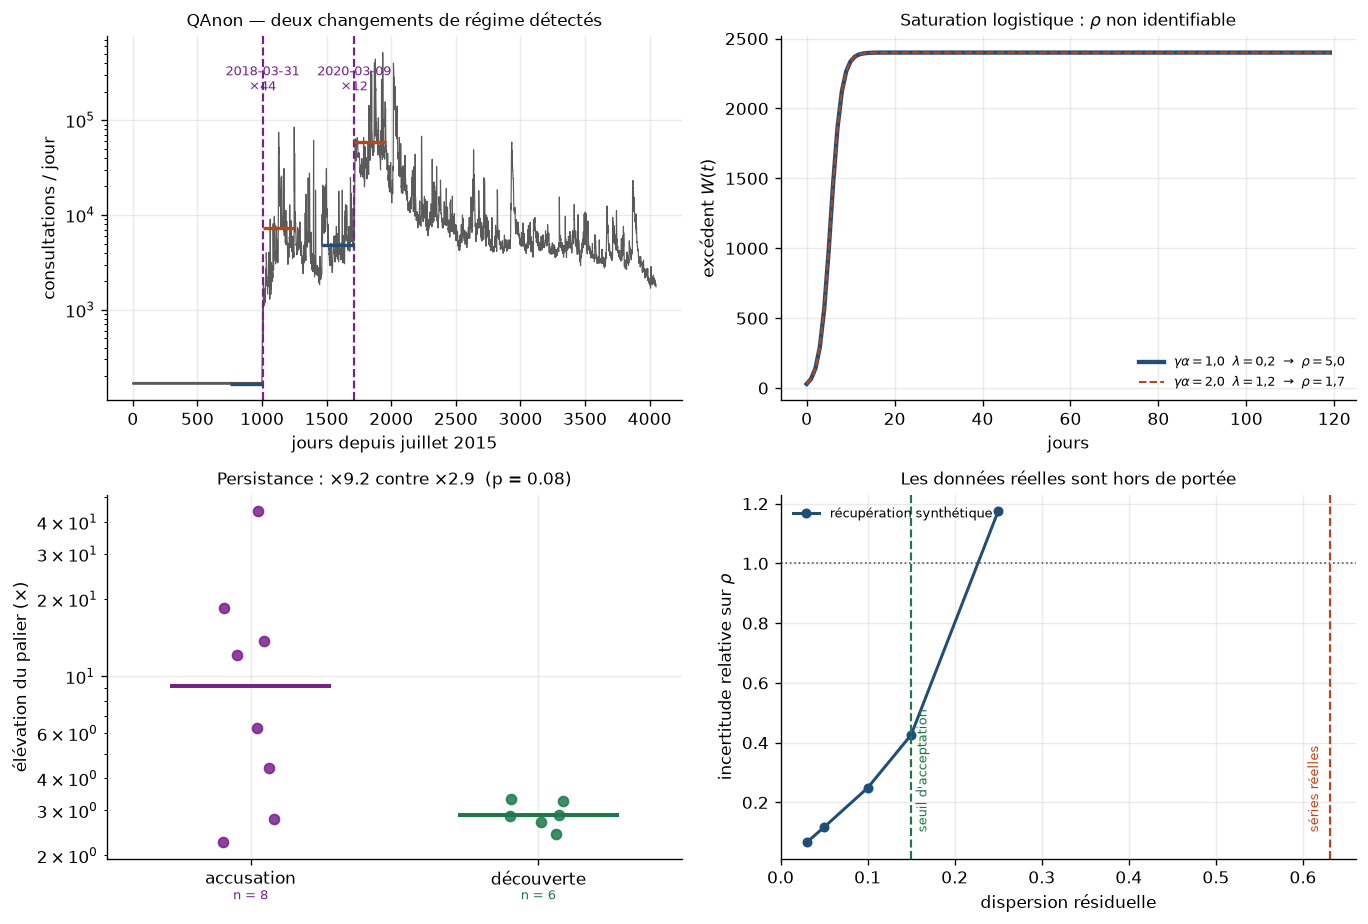

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11.5, 7.8))
example, forms, lifts, precision = axes.ravel()

# (a) Un changement de régime réel, avec sa date détectée.
target = "QAnon"
entry = next(item for item in CORPUS if item.label == target)
series = load_or_fetch(entry.project, entry.article, CORPUS_START, CORPUS_END)
values = weekly_adjust(np.clip(series.filled(), 1.0, None))
report = scan_regime_shifts(np.clip(series.filled(), 1.0, None), label=target)

example.semilogy(np.arange(values.size), values, color=PALETTE["neutral"], linewidth=0.7)
for shift in report.shifts:
    example.axvline(shift.index, color=PALETTE["field"], linestyle="--", linewidth=1.3)
    example.annotate(f"{series.day(shift.index)}\n×{shift.lift:.0f}",
                     xy=(shift.index, values.max() * 0.4), fontsize=7.5,
                     color=PALETTE["field"], ha="center")
    example.hlines(shift.level_before, shift.index - 250, shift.index,
                   color=PALETTE["order"], linewidth=2.0)
    example.hlines(shift.level_after, shift.index, shift.index + 250,
                   color=PALETTE["disorder"], linewidth=2.0)
example.set_xlabel("jours depuis juillet 2015")
example.set_ylabel("consultations / jour")
example.set_title(f"{target} — deux changements de régime détectés", fontsize=10)

# (b) La non-identifiabilité sous saturation logistique.
forms.plot(grid, first, color=PALETTE["order"], linewidth=2.6,
           label=r"$\gamma\alpha=1{,}0$  $\lambda=0{,}2$  →  $\rho = 5{,}0$")
forms.plot(grid, second, color=PALETTE["disorder"], linewidth=1.2, linestyle="--",
           label=r"$\gamma\alpha=2{,}0$  $\lambda=1{,}2$  →  $\rho = 1{,}7$")
forms.set_xlabel("jours")
forms.set_ylabel("excédent $W(t)$")
forms.set_title("Saturation logistique : $\\rho$ non identifiable", fontsize=10)
forms.legend(fontsize=7.5, loc="lower right")

# (c) Élévation du palier, par registre émotionnel.
rng = np.random.default_rng(0)
for position, (category, colour, name) in enumerate(
    [("accusation", PALETTE["field"], "accusation"), ("discovery", PALETTE["remedy"], "découverte")]
):
    values_class = np.array([r["élévation"] for r in records if r["classe"] == category])
    jitter = position + rng.uniform(-0.10, 0.10, size=values_class.size)
    lifts.semilogy(jitter, values_class, "o", color=colour, markersize=6, alpha=0.85)
    lifts.hlines(np.median(values_class), position - 0.28, position + 0.28,
                 color=colour, linewidth=2.4)
    lifts.text(position, 1.35, f"n = {values_class.size}", ha="center", fontsize=8, color=colour)

accusation = np.array([r["élévation"] for r in records if r["classe"] == "accusation"])
discovery = np.array([r["élévation"] for r in records if r["classe"] == "discovery"])
p_value = stats.mannwhitneyu(accusation, discovery, alternative="two-sided").pvalue
lifts.set_xticks([0, 1])
lifts.set_xticklabels(["accusation", "découverte"])
lifts.set_xlim(-0.5, 1.5)
lifts.set_ylabel("élévation du palier (×)")
lifts.set_title(f"Persistance : ×{np.median(accusation):.1f} contre ×{np.median(discovery):.1f}"
                f"  (p = {p_value:.2f})", fontsize=10)

# (d) Incertitude en fonction de la dispersion, et position des séries réelles.
scatters = np.array(sorted(table))
spreads = np.array([table[s][1] for s in scatters])
precision.plot(scatters, spreads, "o-", color=PALETTE["order"], markersize=5,
               label="récupération synthétique")
precision.axhline(1.0, color=PALETTE["neutral"], linestyle=":", linewidth=1.0)
precision.axvline(0.15, color=PALETTE["remedy"], linestyle="--", linewidth=1.3)
precision.text(0.155, 0.1, "seuil d'acceptation", fontsize=7.5, color=PALETTE["remedy"],
               rotation=90, va="bottom")
precision.axvline(observed, color=PALETTE["disorder"], linestyle="--", linewidth=1.3)
precision.text(observed - 0.01, 0.1, "séries réelles", fontsize=7.5,
               color=PALETTE["disorder"], rotation=90, va="bottom", ha="right")
precision.set_xlabel("dispersion résiduelle")
precision.set_ylabel("incertitude relative sur $\\rho$")
precision.set_title("Les données réelles sont hors de portée", fontsize=10)
precision.legend(fontsize=8, loc="upper left")

save_figure(figure, "fig10_regimes.png")
plt.show()

## 7. Un écart entre registres, pour la première fois du projet

Le notebook 09 ne trouvait aucune différence entre contenus d'accusation et annonces
scientifiques : le rapport d'amplification était indiscernable entre les deux, et
l'estimation ponctuelle allait même dans le sens contraire à la prédiction.

La **persistance** dit autre chose. Les changements de régime du registre « accusation »
élèvent le niveau d'attention d'un facteur médian **×9,2**, contre **×2,9** pour les
annonces de découverte — un rapport de trois, avec $p = 0{,}08$.

Ce n'est pas concluant : quatorze observations, un seuil de signification non franchi, et une
réserve supplémentaire — les changements du registre « découverte » se situent tous juste
au-dessus du seuil de détection (×2,4 à ×3,3), ce qui suggère que certains sont des pics à
décroissance lente plutôt que de véritables régimes.

Mais la direction est celle que le modèle prédit, l'écart est net, et il porte sur une
grandeur que le projet n'avait pas encore mesurée. **Ce n'est pas le taux d'amplification
qui distingue les registres émotionnels, c'est la durée pendant laquelle l'attention
reste captée.**

## 8. Ce que le notebook établit

**La détection de changement de régime fonctionne, et couvre l'angle mort.** Quatorze
changements sur le corpus, aux bonnes dates, dans les sujets même que la méthode par pic
manquait. Le détecteur ne produit aucun faux positif sur bruit stationnaire, rejette les
pics, et rejette les créations d'articles.

**L'identification, elle, échoue sur données réelles.** Zéro des quatorze changements livre
des paramètres exploitables : la dispersion résiduelle médiane est de 0,63 là où
l'incertitude devient prohibitive dès 0,15. Ce n'est pas un défaut de l'implémentation — la
récupération est exacte sur trajectoire propre, y compris pour $\rho = 40$ — mais une
inadéquation entre le modèle à trois paramètres et le bruit réel des séries d'attention.

**Et une limite théorique domine les deux.** L'identifiabilité de $\gamma\alpha/\lambda$
sur un changement de régime dépend de la forme supposée de la saturation. Sous saturation
logistique, elle n'existe pas : deux triplets de rapports 5,0 et 1,7 produisent la même
courbe. Le rapport n'est donc pas une grandeur que les données déterminent — c'est une
grandeur que le choix de modèle détermine.

**Ce que cela déplace.** Le mémorandum recommandait de plafonner $\gamma\alpha/\lambda$.
Cette recommandation supposait le rapport mesurable ; il ne l'est ni sur les régimes
installés, ni indépendamment d'une hypothèse de forme. En revanche, deux grandeurs se
mesurent bien et distinguent les registres : **la date du basculement et l'élévation du
palier**. Un cadre réglementaire adossé à celles-ci serait opposable, là où un seuil sur
$\rho$ ne l'est pas.

## Pistes ouvertes

1. **Réduire le modèle plutôt que d'améliorer l'ajustement.** Deux paramètres identifiables
   sans hypothèse de forme — le taux de croissance initial et le niveau du palier — valent
   mieux que trois dont un n'est pas déterminé par les données.
2. **Un observable moins bruité.** La dispersion des consultations quotidiennes est
   irréductible ; des séries agrégées par semaine, ou une mesure directe d'exposition plutôt
   que de consultation, changeraient l'ordre de grandeur.
3. **Étendre le corpus à la persistance.** L'écart ×9,2 contre ×2,9 mérite d'être testé sur
   plusieurs centaines de sujets pré-enregistrés : c'est le seul résultat du projet qui
   distingue les registres émotionnels, et il est actuellement à $p = 0{,}08$.
4. **Vérifier que les régimes « découverte » sont bien des régimes.** Tous se situent juste
   au-dessus du seuil : allonger la durée de maintien exigée trancherait.